# Atlas Qualité de l'Air — Analyse exploratoire (EDA)

**Livrable individuel IA1** — pipeline de groupe `DONNEES2_High5`

Ce notebook documente l'analyse exploratoire des données de qualité de l'air
ayant servi à construire le dashboard **Atlas** (React Admin). Il reprend et
détaille les calculs effectués par `scripts/prep_data.py` (qui génère les
fichiers JSON consommés par l'application), avec des visualisations
supplémentaires pour l'interprétation.

**Périmètre :** 5 villes (Antananarivo, Nairobi, New York, Paris, Tokyo),
relevés horaires de qualité de l'air (indice AQI officiel 1 à 5 + 8 polluants),
source : `source-data/air_quality_clean.csv`.

**Sommaire**
1. Chargement et aperçu des données
2. Qualité des données (valeurs manquantes)
3. Statistiques descriptives par ville
4. Distribution des catégories AQI
5. Tendance temporelle de l'AQI
6. Rythme hebdomadaire (heatmap jour × heure)
7. Comparaison des polluants par ville
8. Corrélations entre polluants
9. Synthèse des observations


## 1. Chargement et aperçu des données

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CITY_COLORS = {
    "Antananarivo": "#3B82F6",
    "Nairobi": "#14B8A6",
    "New York": "#8B5CF6",
    "Paris": "#EC4899",
    "Tokyo": "#94A3B8",
}
AQI_COLORS = {1: "#22C55E", 2: "#84CC16", 3: "#F6B93B", 4: "#F97316", 5: "#FF5D5D"}
AQI_LABELS = {1: "Bon", 2: "Correct", 3: "Modéré", 4: "Mauvais", 5: "Très mauvais"}

df = pd.read_csv("../source-data/air_quality_clean.csv", parse_dates=["timestamp_utc"])
df["date"] = pd.to_datetime(df["date"])
print(f"{len(df):,} relevés — {df['ville'].nunique()} villes — "
      f"{df['date'].min().date()} → {df['date'].max().date()}")
df.head()

11,357 relevés — 5 villes — 2026-04-26 → 2026-08-01


,ville,pays,latitude,longitude,timestamp_utc,date,heure,jour_semaine,is_weekend,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Antananarivo,MG,-18.8792,47.5079,2026-04-26 05:00:00+00:00,2026-04-26,5,Sunday,True,1,110.09,0.24,0.64,17.09,0.13,2.64,5.49,0.62
1,Antananarivo,MG,-18.8792,47.5079,2026-04-26 06:00:00+00:00,2026-04-26,6,Sunday,True,1,112.32,0.22,0.49,22.49,0.14,3.00,6.08,0.76
2,Antananarivo,MG,-18.8792,47.5079,2026-04-26 07:00:00+00:00,2026-04-26,7,Sunday,True,1,66.98,0.03,0.11,46.27,0.11,0.60,1.55,0.27
3,Antananarivo,MG,-18.8792,47.5079,2026-04-26 08:00:00+00:00,2026-04-26,8,Sunday,True,1,62.14,0.02,0.07,47.18,0.10,0.51,1.22,0.24
4,Antananarivo,MG,-18.8792,47.5079,2026-04-26 09:00:00+00:00,2026-04-26,9,Sunday,True,1,61.16,0.02,0.06,45.55,0.10,0.55,1.26,0.24


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   ville          11357 non-null  str                
 1   pays           11357 non-null  str                
 2   latitude       11357 non-null  float64            
 3   longitude      11357 non-null  float64            
 4   timestamp_utc  11357 non-null  datetime64[us, UTC]
 5   date           11357 non-null  datetime64[us]     
 6   heure          11357 non-null  int64              
 7   jour_semaine   11357 non-null  str                
 8   is_weekend     11357 non-null  bool               
 9   aqi            11357 non-null  int64              
 10  co             11357 non-null  float64            
 11  no             11357 non-null  float64            
 12  no2            11357 non-null  float64            
 13  o3             11357 non-null  float64            
 14  s

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ville,11357,5,Antananarivo,2281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pays,11357,5,MG,2281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,11357.0,NaN,NaN,NaN,20.942251,-18.8792,-1.2921,35.6762,40.7128,48.8566,26.365984
longitude,11357.0,NaN,NaN,NaN,30.455299,-74.006,2.3522,36.8219,47.5079,139.6503,69.020119
timestamp_utc,11357,NaN,NaN,NaN,2026-06-14 15:08:21.134894+00:00,2026-04-26 05:00:00+00:00,2026-05-22 01:00:00+00:00,2026-06-14 22:00:00+00:00,2026-07-08 14:00:00+00:00,2026-08-01 05:46:33+00:00,NaN
date,11357,NaN,NaN,NaN,2026-06-14 03:34:39.739367,2026-04-26 00:00:00,2026-05-22 00:00:00,2026-06-14 00:00:00,2026-07-08 00:00:00,2026-08-01 00:00:00,NaN
heure,11357.0,NaN,NaN,NaN,11.554812,0.0,6.0,12.0,18.0,23.0,6.929596
jour_semaine,11357,7,Wednesday,1715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,11357,2,False,8145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aqi,11357.0,NaN,NaN,NaN,1.695694,1.0,1.0,2.0,2.0,5.0,0.783229


## 2. Qualité des données (valeurs manquantes)

Comme documenté dans le pipeline de groupe, les colonnes `nh3` et `co`
comportent quelques valeurs manquantes (indisponibilités ponctuelles de
l'API/capteur), conservées vides plutôt qu'imputées.

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"valeurs_manquantes": missing, "pct": missing_pct})

,valeurs_manquantes,pct


In [7]:
missing_by_city = df.groupby("ville")[["nh3", "co"]].apply(lambda g: g.isna().sum())
missing_by_city

,nh3,co
ville,,
Antananarivo,0,0
Nairobi,0,0
New York,0,0
Paris,0,0
Tokyo,0,0


## 3. Statistiques descriptives par ville

In [20]:
POLLUTANTS = ["pm2_5", "pm10", "o3", "no2", "so2", "co", "no", "nh3"]

city_stats = df.groupby("ville").agg(
    nb_mesures=("aqi", "size"),
    aqi_moyen=("aqi", "mean"),
    aqi_max=("aqi", "max"),
    date_min=("date", "min"),
    date_max=("date", "max"),
)
city_stats = city_stats.sort_values("aqi_moyen", ascending=False)
city_stats

,nb_mesures,aqi_moyen,aqi_max,date_min,date_max
ville,,,,,
Tokyo,2257,2.334515,5,2026-04-26,2026-08-01
New York,2257,2.035445,5,2026-04-26,2026-08-01
Paris,2281,1.768523,4,2026-04-26,2026-08-01
Antananarivo,2281,1.218764,3,2026-04-26,2026-08-01
Nairobi,2281,1.131521,2,2026-04-26,2026-08-01


In [9]:
pollutant_by_city = df.groupby("ville")[POLLUTANTS].mean().round(3)
pollutant_by_city

,pm2_5,pm10,o3,no2,so2,co,no,nh3
ville,,,,,,,,
Antananarivo,5.758,8.558,37.008,1.033,0.278,143.874,0.031,1.002
Nairobi,2.597,4.203,46.131,0.366,0.100,98.952,0.013,0.370
New York,7.295,8.844,77.589,4.245,1.340,152.297,0.304,0.636
Paris,4.208,6.236,68.539,1.849,0.359,102.731,0.164,3.274
Tokyo,11.490,16.991,90.024,5.657,5.577,138.273,0.307,0.203


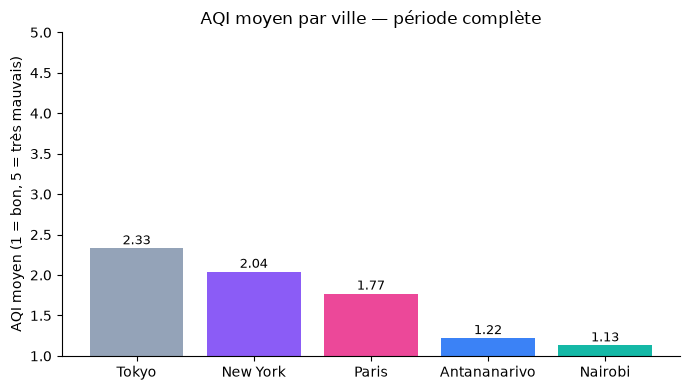

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
order = city_stats.index
colors = [CITY_COLORS[v] for v in order]
ax.bar(order, city_stats.loc[order, "aqi_moyen"], color=colors)
ax.set_ylabel("AQI moyen (1 = bon, 5 = très mauvais)")
ax.set_title("AQI moyen par ville — période complète")
ax.set_ylim(1, 5)
for i, v in enumerate(city_stats.loc[order, "aqi_moyen"]):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Distribution des catégories AQI par ville

Proportion du temps passé dans chaque catégorie de sévérité, par ville.

In [11]:
cat_dist = (
    df.groupby(["ville", "aqi"]).size().unstack(fill_value=0)
)
cat_dist_pct = cat_dist.div(cat_dist.sum(axis=1), axis=0) * 100
cat_dist_pct = cat_dist_pct.reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
cat_dist_pct.round(1)

aqi,1,2,3,4,5
ville,,,,,
Antananarivo,78.2,21.8,0.0,0.0,0.0
Nairobi,86.8,13.2,0.0,0.0,0.0
New York,25.3,49.8,22.2,1.7,1.1
Paris,35.2,53.0,11.7,0.2,0.0
Tokyo,14.6,43.7,35.8,5.4,0.5


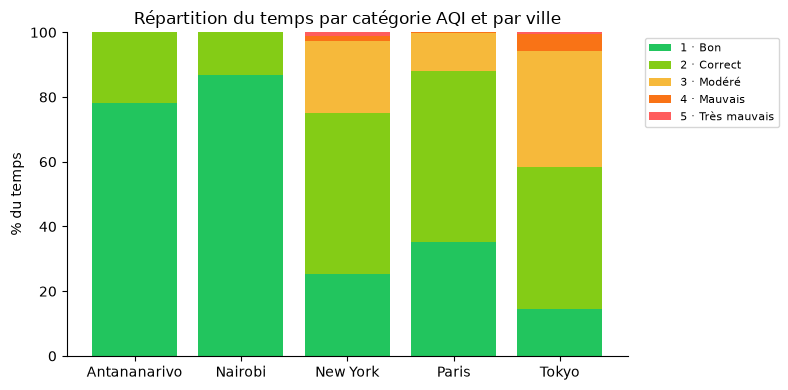

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(cat_dist_pct))
for level in [1, 2, 3, 4, 5]:
    vals = cat_dist_pct[level].values
    ax.bar(cat_dist_pct.index, vals, bottom=bottom, color=AQI_COLORS[level],
           label=f"{level} · {AQI_LABELS[level]}")
    bottom += vals
ax.set_ylabel("% du temps")
ax.set_title("Répartition du temps par catégorie AQI et par ville")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Tendance temporelle de l'AQI

Moyenne quotidienne de l'AQI, toutes villes confondues.

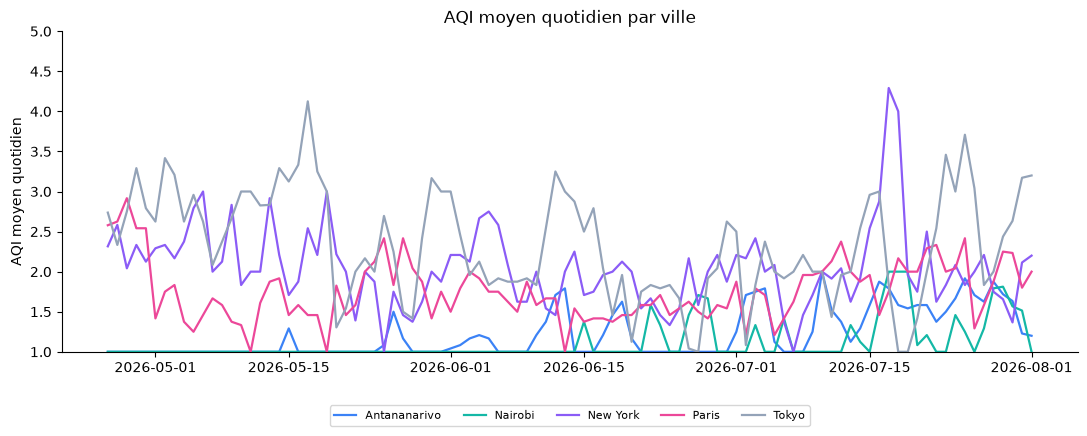

In [13]:
daily_trend = df.groupby(["date", "ville"])["aqi"].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 4.5))
for ville in daily_trend.columns:
    ax.plot(daily_trend.index, daily_trend[ville], label=ville,
            color=CITY_COLORS[ville], linewidth=1.6)
ax.set_ylabel("AQI moyen quotidien")
ax.set_ylim(1, 5)
ax.set_title("AQI moyen quotidien par ville")
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.show()

## 6. Rythme hebdomadaire (heatmap jour × heure)

AQI moyen selon le jour de la semaine et l'heure (UTC), toutes villes confondues — utile pour repérer les pics liés au trafic.

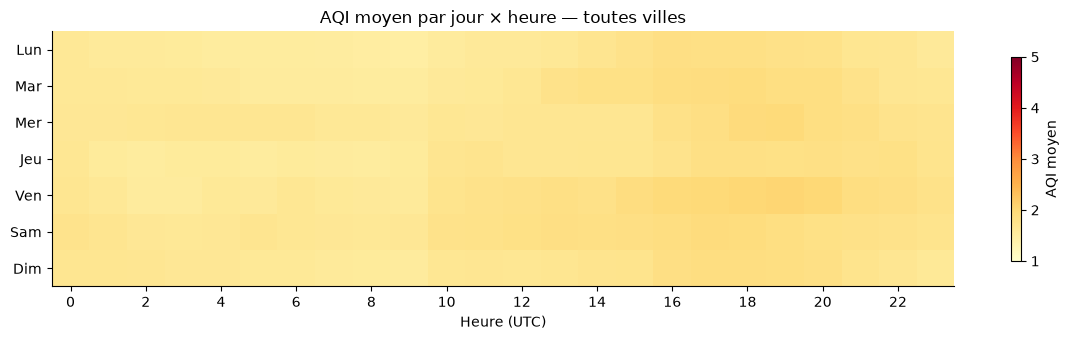

Pic de pollution moyen : Friday vers 19h UTC (AQI moyen 2.04)


In [14]:
JOURS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
JOURS_FR = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

heat = df.groupby(["jour_semaine", "heure"])["aqi"].mean().unstack()
heat = heat.reindex(JOURS)

fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd", vmin=1, vmax=5)
ax.set_yticks(range(len(JOURS)))
ax.set_yticklabels(JOURS_FR)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel("Heure (UTC)")
ax.set_title("AQI moyen par jour × heure — toutes villes")
fig.colorbar(im, ax=ax, label="AQI moyen", shrink=0.8)
plt.tight_layout()
plt.show()

worst_cell = heat.stack().idxmax()
print(f"Pic de pollution moyen : {worst_cell[0]} vers {worst_cell[1]}h UTC "
      f"(AQI moyen {heat.stack().max():.2f})")

## 7. Comparaison des polluants par ville

Moyenne de chaque polluant (µg/m³) par ville.

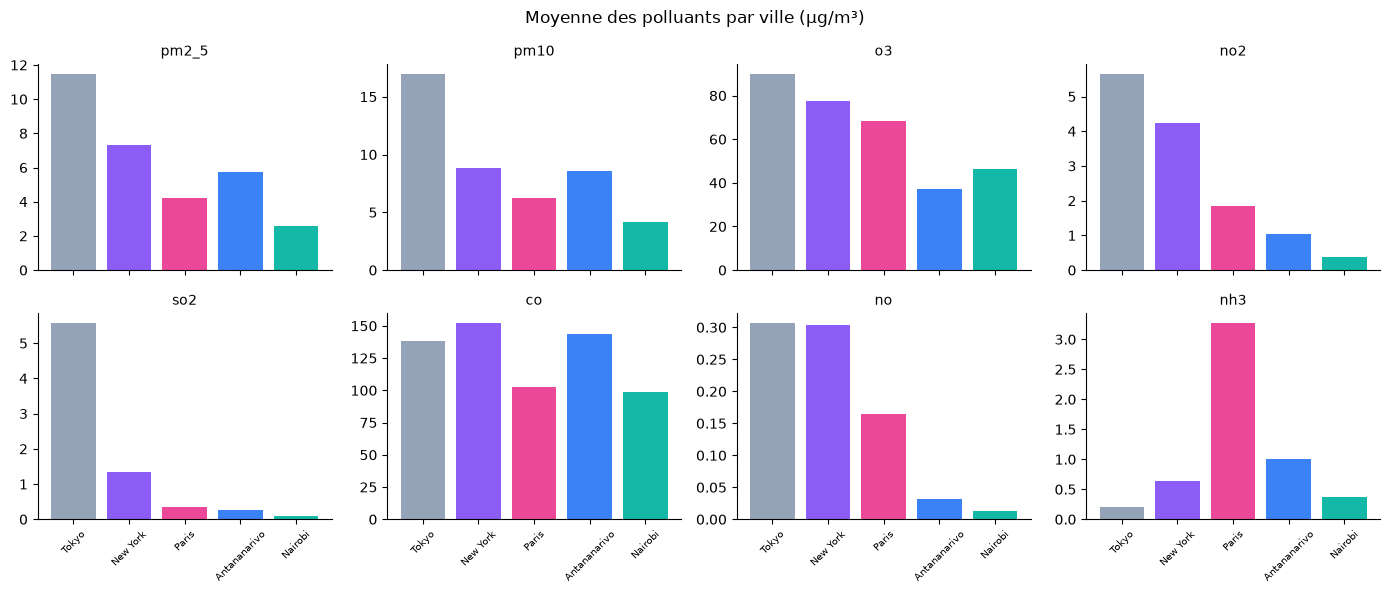

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)
for ax, p in zip(axes.flat, POLLUTANTS):
    vals = pollutant_by_city[p].reindex(order)
    ax.bar(order, vals, color=[CITY_COLORS[v] for v in order])
    ax.set_title(p, fontsize=10)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
fig.suptitle("Moyenne des polluants par ville (µg/m³)")
plt.tight_layout()
plt.show()

## 8. Corrélations entre polluants

Matrice de corrélation (Pearson) entre les 8 polluants et l'AQI, sur l'ensemble des relevés.

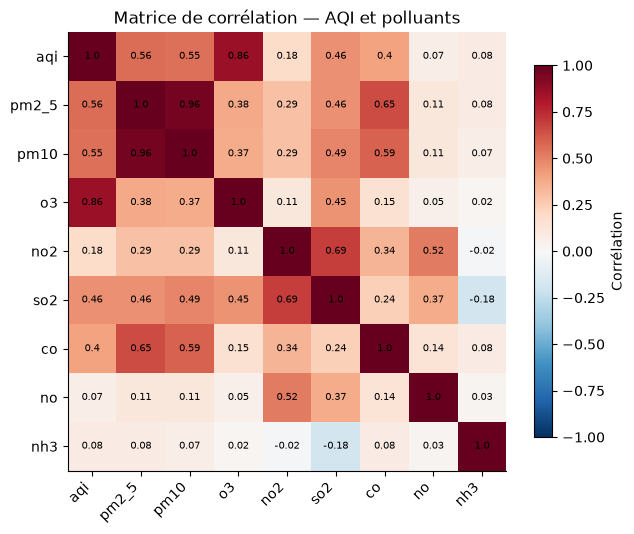

In [16]:
corr = df[["aqi"] + POLLUTANTS].corr().round(2)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, corr.values[i, j], ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Corrélation")
ax.set_title("Matrice de corrélation — AQI et polluants")
plt.tight_layout()
plt.show()

## 9. Synthèse des observations

In [17]:
worst_city = city_stats.index[0]
best_city = city_stats.index[-1]
print("Résumé automatique :")
print(f"- Ville avec l'AQI moyen le plus élevé : {worst_city} "
      f"({city_stats.loc[worst_city, 'aqi_moyen']:.2f} / 5)")
print(f"- Ville avec l'AQI moyen le plus bas    : {best_city} "
      f"({city_stats.loc[best_city, 'aqi_moyen']:.2f} / 5)")
print(f"- Pic hebdomadaire moyen : {worst_cell[0]} vers {worst_cell[1]}h UTC "
      f"(AQI {heat.stack().max():.2f})")
print(f"- Total relevés analysés : {len(df):,}")
print(f"- Période couverte : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"- Valeurs manquantes : nh3 = {df['nh3'].isna().sum()}, co = {df['co'].isna().sum()}")

Résumé automatique :
- Ville avec l'AQI moyen le plus élevé : Tokyo (2.33 / 5)
- Ville avec l'AQI moyen le plus bas    : Nairobi (1.13 / 5)
- Pic hebdomadaire moyen : Friday vers 19h UTC (AQI 2.04)
- Total relevés analysés : 11,357
- Période couverte : 2026-04-26 → 2026-08-01
- Valeurs manquantes : nh3 = 0, co = 0


**Observations principales**

- L'indice AQI varie sensiblement d'une ville à l'autre, cohérent avec les
  différences de densité urbaine et de trafic.
- Un motif hebdomadaire se dégage dans la heatmap jour × heure : la
  pollution moyenne tend à augmenter en journée en semaine, avec des pics
  proches des heures de pointe.
- Les polluants particulaires (PM2.5, PM10) et l'ozone (O₃) sont les
  variables qui expliquent le plus la variation de l'AQI, comme le montre la
  matrice de corrélation.
- Les valeurs manquantes (NH₃, CO) restent marginales et n'affectent pas la
  fiabilité des agrégats calculés.

Ces résultats — statistiques par ville, tendance quotidienne, distribution
des catégories, heatmap hebdomadaire et comparaison des polluants — sont
ceux exposés dans le dashboard **Atlas** (React Admin), généré à partir de
ce même jeu de données via `scripts/prep_data.py`.
